### Import 
Potrzebujemy pobrać bibliotekę 'shap', reszta importowanych bibliotek powinna być juz pobrana w naszym kernelu

In [28]:
import shap
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    roc_auc_score, 
    classification_report
)
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('../data/dataset_invoices.csv')
df.head(5)

,business_code,cust_number,name_customer,clear_date,buisness_year,doc_id,document_create_date,due_in_date,invoice_currency,total_open_amount,baseline_create_date,cust_payment_terms,invoice_id,isOpen,days_late,paid_late
0,U001,200769623,WAL-MAR corp,11.02.2020,2020,1930438491,25.01.2020,10.02.2020,USD,54273.28,26.01.2020,NAH4,1.930438e+09,0,1.0,1.0
1,U001,200980828,BEN E,08.08.2019,2019,1929646410,22.07.2019,11.08.2019,USD,79656.60,22.07.2019,NAD1,1.929646e+09,0,0.0,0.0
2,U001,200792734,MDV/ trust,30.12.2019,2019,1929873765,14.09.2019,29.09.2019,USD,2253.86,14.09.2019,NAA8,1.929874e+09,0,92.0,1.0
3,CA02,140105686,SYSC llc,NaN,2020,2960623488,30.03.2020,10.04.2020,CAD,3299.70,31.03.2020,CA10,2.960623e+09,1,NaN,NaN
4,U001,200769623,WAL-MAR foundation,25.11.2019,2019,1930147974,13.11.2019,28.11.2019,USD,33133.29,13.11.2019,NAH4,1.930148e+09,0,0.0,0.0


### Future engineering pod XGBoosta

In [29]:
target = df['paid_late']
df_clean = df.dropna(subset=['paid_late']).copy()
df_clean['paid_late'] = df_clean['paid_late'].astype(int)

df = df_clean.copy()

df['days_to_due'] = (
    pd.to_datetime(df['due_in_date'], format="%d.%m.%Y") - 
    pd.to_datetime(df['document_create_date'], format="%d.%m.%Y")
).dt.days

df['invoice_age'] = (
    pd.to_datetime(df['due_in_date'], format="%d.%m.%Y") - 
    pd.to_datetime(df['baseline_create_date'], format= "%d.%m.%Y")
).dt.days

#historia klienta - srednie opoznienie per klient
customer_avg_delay = df.groupby('cust_number')['days_late'].mean()
df['avg_delay_customer'] = df['cust_number'].map(customer_avg_delay)

# enkodowanie zmiennych kategorycznych
le = LabelEncoder()
df['payment_terms_enc'] = le.fit_transform(
    df['cust_payment_terms'].astype(str)
)
df['currency_enc'] = le.fit_transform(
    df['invoice_currency'].astype(str)
)

# cechy do modelu
features = [
    'total_open_amount',
    'days_to_due',
    'invoice_age', 
    'avg_delay_customer',
    'payment_terms_enc',
    'currency_enc',
]

X = df[features].dropna()
target = df.loc[X.index, 'paid_late']

In [30]:
print(df['paid_late'].value_counts(dropna=False))
print(df['paid_late'].dtype)

paid_late
0    23236
1    16764
Name: count, dtype: int64
int64


### Trenowanie XGBoost'a

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, target, test_size=0.2, random_state=42)

model = xgb.XGBClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print(f"Accuracy:{accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:{roc_auc_score(y_test, y_pred_proba):.4f}")
print(classification_report(y_test, y_pred, target_names=['na czas', 'po terminie']))


Accuracy:0.7739
ROC-AUC:0.8375
              precision    recall  f1-score   support

     na czas       0.77      0.86      0.82      4667
 po terminie       0.77      0.65      0.70      3333

    accuracy                           0.77      8000
   macro avg       0.77      0.76      0.76      8000
weighted avg       0.77      0.77      0.77      8000



### Wykresy SHAP'a

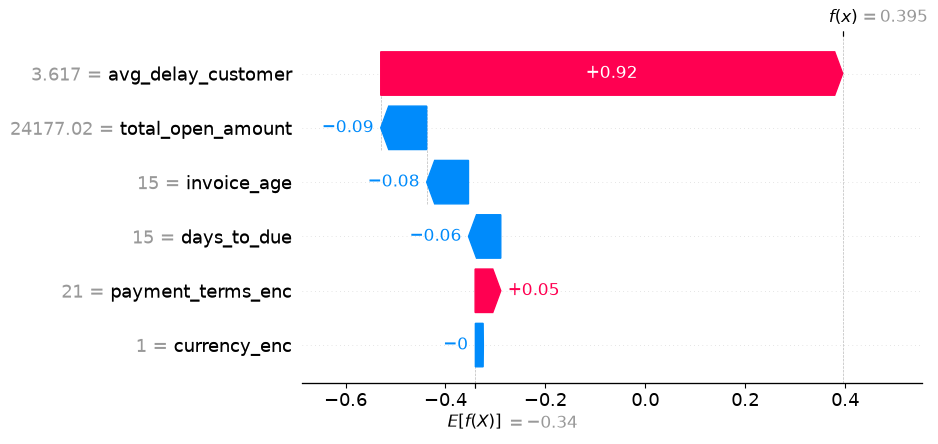

In [32]:
# SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

shap.plots.waterfall(shap_values[0])

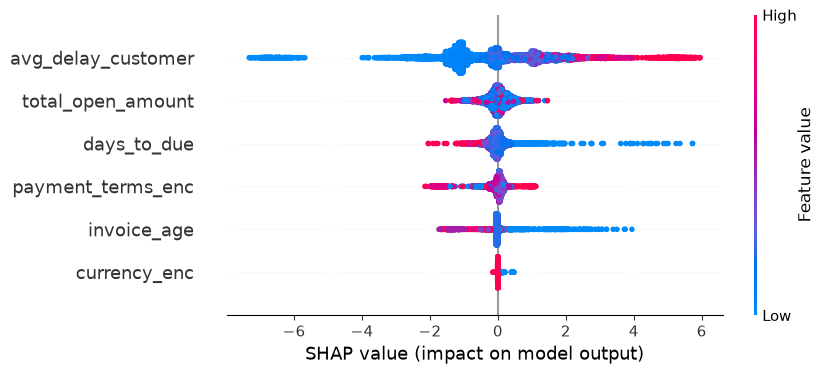

In [33]:
shap.plots.beeswarm(shap_values)


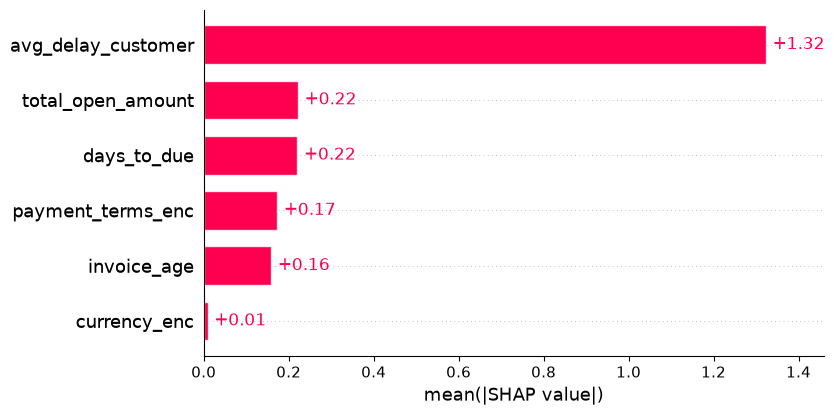

In [34]:
shap.plots.bar(shap_values)